**Justin Hovious**

**5/2/2026**

**Wave Energy Farm Power Prediction Using Linear Regression**

In [3]:
pip install lazypredict

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 71.0/71.0 kB 2.4 MB/s eta 0:00:00


In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PolynomialFeatures

from sklearn.metrics import root_mean_squared_error
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

In [6]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [7]:
data = pd.read_csv("/content/drive/MyDrive/Machine Learning/CSCI 460/Large-scale Wave Energy Farm/WEC_Perth_49.csv")
df = pd.DataFrame(data)

In [8]:
# Removing XY coordinate columns since they aren't useful for prediction
df = df.drop(columns=[col for col in df.columns if col.startswith(('X', 'Y'))])
print(df.shape)

(36043, 51)


In [10]:
# Features and target
X = df.drop(columns=['Total_Power'])
y = df['Total_Power']

# Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [11]:
print(f"X Train shape: {X_train.shape}")
print(f"y Train shape: {y_train.shape}")
print(f"X Test shape: {X_test.shape}")
print(f"y Test shape: {y_test.shape}")

X Train shape: (28834, 50)
y Train shape: (28834,)
X Test shape: (7209, 50)
y Test shape: (7209,)


In [13]:
# Instantiating a basic Linear Regression Model
lin_reg = LinearRegression()

# Training the model
lin_reg.fit(X_train, y_train)

LinearRegression()

In [15]:
# Making predictitons and computing accuracy metrics
y_pred = lin_reg.predict(X_test)

print('MAE: {}'.format(mean_absolute_error(y_test, y_pred)))
print('MSE: {}'.format(mean_squared_error(y_test, y_pred)))
print('RMSE: {}'.format(root_mean_squared_error(y_test, y_pred)))
print('R2 score: {}'.format(r2_score(y_test, y_pred)))

MAE: 289.24799162963785
MSE: 181428.83652935983
RMSE: 425.9446402167303
R2 score: 0.9999876899690634


**Interpreted Results**

MAE: 289 indicates the average absolute error is only 289 watts which is extremely small considering the mean for Total Power is 3,938,246.

RMSE: 425 indicates the typical prediction error is about 425 which again, is very good considering the magnitute of Total Power

R2: ~0.99998 indicates the model explains ~99.99998% of the variance in Total Power.

These results indicate that our model is performing extremely well.

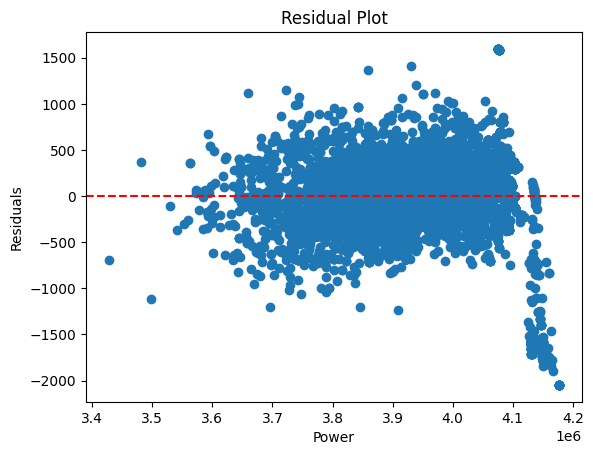

In [18]:
residuals = (y_test - y_pred)

%matplotlib inline
plt.scatter(y_test, residuals)
plt.ylabel('Residuals')
plt.xlabel('Power')
plt.title('Residual Plot')
plt.axhline(0, color='red', linestyle='--')

**Interpreted Results**

The residuals plot shows random scatter, evenly spread above and below 0 with only a few relative clusters near the high end of the x-axis. Since there is no discernable shape, patttern, or clusters, the residuals appear to be randomly distributed. This indicatets that the model successfully captured the relationship between the features and the target.